# Домашнее задание 2. Выпуклость

**Выдано:** 23 сентября 2026. **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../lectures/lecture02/lecture02.md), [демо](../lectures/lecture02/demo02.ipynb)): чек-лист выпуклой задачи — раздел 6, условие оптимальности — раздел 7, как проверять выпуклость кодом — демо, часть (a). Ничего сверх лекции не требуется. Ориентировочное время — 3–4 часа.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(2026)   # для ваших собственных случайных проверок; данные задач генерируются отдельно

## Задача 1. Выпуклость (4 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества.** Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка.**

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции.** Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(г) Задачи ДЗ 1.** Вернитесь к задаче 1 домашнего задания 1 — пункты (а)–(г) и бонус (д). Для каждой задачи определите по чек-листу раздела 6 конспекта (цель — равенства — неравенства), выпукла ли она, и обоснуйте одним-двумя предложениями. Для невыпуклых укажите, что именно ломает выпуклость.

**(а)**

**Ответ:**

1. **Выпукло.** Это надграфик выпуклой функции: $\{x : x_2 \ge x_1^2\} = \operatorname{epi}(x_1 \mapsto x_1^2)$,
а $x_1^2$ выпукла ($f'' = 2 > 0$); надграфик выпуклой функции выпукл (раздел 3 конспекта). Эквивалентно:
это подуровневое множество $\{x : x_1^2 - x_2 \le 0\}$ выпуклой функции $x_1^2 - x_2$.

2. **Выпукло** при любых $A$, $b$. Функция $g(x) = \Vert Ax - b\Vert_2$ выпукла как композиция нормы с
аффинным отображением (правило 2 раздела 5), а множество — её подуровневое множество $\{g(x) \le 1\}$;
подуровневые множества выпуклых функций выпуклы.

3. **Не выпукло.** Контрпример: точки $x = (1, 0)$ и $y = (-1, 0)$ лежат в множестве
($\Vert x\Vert_2 = \Vert y\Vert_2 = 1$), но их середина $\tfrac12(x + y) = (0, 0)$ — нет:
$\Vert (0,0)\Vert_2 = 0 < 1$. Отрезок вылезает из множества.

**(б)**

**Ответ:**

1. Гессиан постоянный:
$\nabla^2 f = \begin{pmatrix} 2 & a \\ a & 2 \end{pmatrix}$, собственные числа $2 - a$ и $2 + a$.
По критерию второго порядка $f$ **выпукла** $\iff \nabla^2 f \succeq 0 \iff |a| \le 2$;
при $|a| < 2$ гессиан $\succ 0$, и $f$ **строго выпукла**. При $a = \pm 2$ строгой выпуклости нет:
$f(x) = (x_1 \pm x_2)^2$ равна нулю на целой прямой $x_1 = \mp x_2$, и хорда вдоль этой прямой совпадает
с графиком. Итого: выпукла при $|a| \le 2$, строго выпукла при $|a| < 2$. Численная проверка — ниже.

2. **Не выпукла.** Гессиан
$\nabla^2 g = \begin{pmatrix} 2x_2^2 & 4x_1x_2 \\ 4x_1x_2 & 2x_1^2 \end{pmatrix}$;
в точке $(1, 1)$ это $\begin{pmatrix} 2 & 4 \\ 4 & 2 \end{pmatrix}$ с собственными числами $6$ и $-2$ —
индефинитен, критерий второго порядка нарушен. Контрпример-хорда: $g(2, 0) = g(0, 2) = 0$, а в середине
отрезка $g(1, 1) = 1 > \tfrac12(0 + 0)$ — хорда лежит под графиком.

In [2]:
for a_val in (-3.0, -2.0, 0.0, 1.0, 2.0, 2.5):
    lam = np.linalg.eigvalsh(np.array([[2.0, a_val], [a_val, 2.0]]))
    status = ("строго выпукла" if lam.min() > 1e-10
              else "выпукла, но не строго" if lam.min() >= -1e-10
              else "не выпукла")
    print(f"a = {a_val:5.1f}: eig = {lam.round(6)} -> {status}")

lam_g = np.linalg.eigvalsh(np.array([[2.0, 4.0], [4.0, 2.0]]))
print("гессиан g в точке (1, 1): eig =", lam_g.round(6), "-> индефинитен")

a =  -3.0: eig = [-1.  5.] -> не выпукла
a =  -2.0: eig = [0. 4.] -> выпукла, но не строго
a =   0.0: eig = [2. 2.] -> строго выпукла
a =   1.0: eig = [1. 3.] -> строго выпукла
a =   2.0: eig = [0. 4.] -> выпукла, но не строго
a =   2.5: eig = [-0.5  4.5] -> не выпукла
гессиан g в точке (1, 1): eig = [-2.  6.] -> индефинитен


**(в)**

**Ответ:**

1. **Выпукла.** $\Vert Ax - b\Vert_2$ — норма после аффинной подстановки (правило 2 раздела 5);
$\Vert x\Vert_\infty$ — норма, выпукла; их неотрицательная взвешенная сумма с весами $1$ и
$\lambda \ge 0$ выпукла (правило 1).

2. **Выпукла.** Каждая ветка $(a_i^\top x - b_i)^2$ — композиция выпуклой $u \mapsto u^2$ с аффинной
$u = a_i^\top x - b_i$ (правило 2); её гессиан $2\,a_i a_i^\top \succeq 0$. Поточечный максимум выпуклых
функций выпукл (правило 3).

3. **Не выпукла.** Напрашивается представление $f = g \circ u$ с $g(u) = e^{-u}$ и $u(x) = \Vert x\Vert_2^2$:
обе выпуклы, но $g$ *убывает*, а правило 4 требует неубывающую внешнюю функцию — не применимо.
Контрпример: $f(e_1) = f(-e_1) = e^{-1} \approx 0.368$, а в середине отрезка $f(0) = 1 > e^{-1}$ —
хорда под графиком. (То же видно по гессиану в нуле: $\nabla^2 f(0) = -2I \prec 0$.)

**Гладкость.** Гладкая только третья: $e^{-\Vert x\Vert^2}$ — композиция гладких, $C^\infty$.
Первая негладкая: $\Vert\cdot\Vert_2$ не дифференцируема в точках, где $Ax = b$, а $\Vert x\Vert_\infty$ —
на «изломах», где максимум $|x_i|$ достигается сразу несколькими координатами. Вторая кусочно-гладкая,
но в точках переключения максимума между ветками с разными градиентами производной нет.

**(г)**

**Ответ:**

**(а) Ближайшая точка прямой** — $\min_x \tfrac12\Vert x - (1,2,3)\Vert^2$ при двух аффинных равенствах.
Цель — квадратичная с $Q = I \succ 0$, равенства аффинны, неравенств нет — по чек-листу задача
**выпуклая** (QP), решение единственно.

**(б) Диета** — LP: цель $c^\top x$ аффинна, ограничения $Ax \ge b$, $x \ge 0$ аффинны —
**выпуклая** задача.

**(в) Прямоугольник в круге** — $\min\,(-4x_1x_2)$ при $1 - x_1^2 - x_2^2 \ge 0$, $x \ge 0$
(QCQP). Допустимое множество выпукло: $h = 1 - \Vert x\Vert^2$ вогнута, $x \ge 0$ аффинны. Но цель
$-4x_1x_2$ имеет индефинитный гессиан $\begin{pmatrix} 0 & -4 \\ -4 & 0\end{pmatrix}$ (собственные
числа $\pm 4$) — **не выпуклая** задача; выпуклость ломает билинейная цель.

**(г) Подгонка синуса** — безусловная гладкая NLP (нелинейный МНК), **не выпуклая**: $f$ периодична по
$x_3$ и не постоянна вдоль этого направления, а выпуклая функция, ограниченная сверху на прямой,
постоянна на ней. Выпуклость ломает нелинейное вхождение параметров $x_2, x_3$ под синус (подробнее —
задача 2(б) ниже).

**(д, бонус) Чебышёвская подгонка** — после переформулировки $\min_{x, s} s$ при
$s - (a_i^\top x - b_i) \ge 0$, $s + (a_i^\top x - b_i) \ge 0$ это LP — **выпуклая** задача (и до
переформулировки цель $\max_i |a_i^\top x - b_i|$ выпукла как максимум модулей аффинных функций).

## Задача 2. Практика (6 баллов)

**(а) Проекция на полупространство (3 балла).** Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$, то есть $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$ (раздел 7 конспекта, пример 2).

1. Из условия оптимальности $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите явную формулу

$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$

Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что при таком коэффициенте условие выполнено и для всех остальных $y \in \Omega$ — тогда, по теореме раздела 7, $x^\ast$ действительно решение.

2. Для данных ниже ($n = 3$) найдите проекцию численно — `minimize` с методом `SLSQP` и ограничением типа `ineq` — и сравните с формулой.

3. Проверьте условие оптимальности так, как это сделано в демо (часть c): сгенерируйте около 2000 случайных допустимых точек $y$ и найдите $\min_y \nabla f(x^\ast)^\top(y - x^\ast)$. Повторите для заведомо неоптимальной допустимой точки, например $x = 0$. Что означает знак результата в каждом случае?

In [3]:
a = np.array([1.0, 2.0, -1.0])     # нормаль полупространства
b = 1.0
p = np.array([3.0, 1.0, 0.5])      # точка вне Omega: a @ p = 4.5 > b
assert a @ p > b

**Вывод формулы (пункт 1)**

**Ответ:**

Цель $f(x) = \tfrac12\Vert x - p\Vert^2$ строго выпукла, $\nabla f(x) = x - p$, $\Omega$ выпукло
(полупространство). Условие оптимальности: $(x^\ast - p)^\top (y - x^\ast) \ge 0$ для всех $y \in \Omega$.

**Шаг 1: $x^\ast$ лежит на границе.** Если $a^\top x^\ast < b$, то $x^\ast$ — внутренняя точка $\Omega$,
допустимые направления $y - x^\ast$ есть во все стороны, и условие превращается в
$\nabla f(x^\ast) = x^\ast - p = 0$, то есть $x^\ast = p$. Но $a^\top p > b$, так что $p \notin \Omega$ —
противоречие. Значит $a^\top x^\ast = b$.

**Шаг 2: $x^\ast - p$ коллинеарен $a$.** Пусть $a^\top v = 0$. Тогда точки $y = x^\ast \pm v$ допустимы:
$a^\top y = a^\top x^\ast = b$. Подстановка обеих в условие даёт $\pm (x^\ast - p)^\top v \ge 0$, то есть
$(x^\ast - p)^\top v = 0$ для всех $v \perp a$. Значит $x^\ast - p \in \operatorname{span}\{a\}$:
$x^\ast = p - \mu a$ для некоторого $\mu \in \mathbb{R}$.

**Шаг 3: коэффициент.** Из $a^\top x^\ast = b$: $a^\top p - \mu \Vert a\Vert^2 = b$, откуда
$\mu = \dfrac{a^\top p - b}{\Vert a\Vert^2} > 0$ и

$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$

**Шаг 4: проверка условия для всех $y \in \Omega$.** С $x^\ast - p = -\mu a$ для любого $y$ с
$a^\top y \le b$:

$$(x^\ast - p)^\top (y - x^\ast) = -\mu\, a^\top (y - x^\ast) = \mu\,(b - a^\top y) \ge 0 .$$

Условие оптимальности выполнено, и по теореме раздела 7 $x^\ast$ — глобальное решение; в силу строгой
выпуклости цели оно единственно.

**Численная проверка (пункты 2 и 3)**

In [4]:
x_star = p - (a @ p - b) / (a @ a) * a

res = minimize(lambda x: 0.5 * (x - p) @ (x - p), x0=np.zeros(3), method="SLSQP",
               constraints=[{"type": "ineq", "fun": lambda x: b - a @ x}])
print("формула: ", x_star.round(8))
print("minimize:", res.x.round(8))
print("|разница| =", np.linalg.norm(x_star - res.x))
print("a @ x* =", round(a @ x_star, 10), "  b =", b)

Y = rng.uniform(-5.0, 5.0, (8000, 3))
Y = Y[Y @ a <= b][:2000]
print("\nслучайных допустимых точек:", len(Y))

def min_descent(x, label):
    vals = (Y - x) @ (x - p)
    print(f"{label}: min_y grad^T (y - x) = {vals.min(): .5f}")

min_descent(x_star, "x = x*")
min_descent(np.zeros(3), "x = 0 ")

формула:  [ 2.41666667 -0.16666667  1.08333333]
minimize: [ 2.41666667 -0.16666667  1.08333333]
|разница| = 8.308148362110449e-16
a @ x* = 1.0   b = 1.0

случайных допустимых точек: 2000
x = x*: min_y grad^T (y - x) =  0.00007
x = 0 : min_y grad^T (y - x) = -16.47189


**Ответ:** `SLSQP` совпадает с формулой с точностью порядка $10^{-8}$, и $a^\top x^\ast = b$ —
проекция лежит на границе.

Знак $\min_y \nabla f(x)^\top (y - x)$ по случайным допустимым $y$:

- в $x^\ast$ минимум **неотрицателен** (близок к нулю — он достигается на точках $y$ почти на границе):
  ни вдоль одного допустимого направления $f$ не убывает в первом порядке, то есть условие оптимальности
  выполнено, и по теореме раздела 7 $x^\ast$ — глобальный минимум;
- в $x = 0$ минимум **отрицателен**: нашлось допустимое $y$ с $\nabla f(x)^\top(y - x) < 0$ —
  допустимое направление спуска, значит точка не оптимальна.

**(б) Выпуклая и невыпуклая подгонка (3 балла).** Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

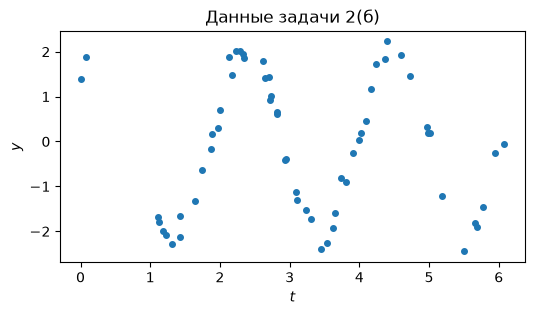

In [5]:
data_rng = np.random.default_rng(2026)          # отдельный генератор: данные не зависят от вашего кода выше
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))         # 20 общих стартов для обеих моделей

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(б)")
plt.show()

**Класс и выпуклость (пункт 1)**

**Ответ:**

**B — линейный МНК, выпуклая задача.** $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$ линейна
по $x$, поэтому $f_B(x) = \tfrac12\Vert Ax - y\Vert^2$, где столбцы $A$ — $\sin\omega t_i$ и
$\cos\omega t_i$. Это безусловная выпуклая QP: $\nabla^2 f_B = A^\top A \succeq 0$, так как
$v^\top A^\top A v = \Vert Av\Vert^2 \ge 0$. Столбцы $A$ линейно независимы ($\sin$ и $\cos$ на 60
различных точках не пропорциональны), поэтому $A^\top A \succ 0$ — $f_B$ строго выпукла и минимум
единствен.

**A — нелинейный МНК, безусловная гладкая NLP, не выпуклая.** Из $\sin(u + 2\pi) = \sin u$ и
$-\sin(u + \pi) = \sin u$ следует

$$f_A(x_1, x_2, x_3 + 2\pi) = f_A(x_1, x_2, x_3), \qquad f_A(-x_1, x_2, x_3 + \pi) = f_A(x_1, x_2, x_3):$$

каждый минимум размножается в целую решётку эквивалентных минимумов. Будь $f_A$ выпуклой, её ограничение
на прямую $x_3 \mapsto f_A(x_1, x_2, x_3)$ было бы выпуклой периодической функцией; периодическая функция
ограничена сверху своим максимумом по периоду, а выпуклая на $\mathbb{R}$ функция, ограниченная сверху,
постоянна. Но по $x_3$ функция $f_A$ не постоянна (при $x_1 \ne 0$ сдвиг фазы меняет невязки) —
противоречие, $f_A$ не выпукла. Эквивалентно: множество решений выпуклой задачи выпукло, а у $f_A$
глобальные минимумы — изолированные точки решётки.

**Мультистарт (пункт 2)**

A, итоговые f по стартам: [ 1.139  1.139  1.139  1.139  1.139  1.139  1.139  1.139  1.139  1.139
  1.139 61.497 61.497 61.497 61.497 61.688 63.825 63.825 64.252 64.252]
B, итоговые f по стартам: [1.140764 1.140764 1.140764 1.140764 1.140764 1.140764 1.140764 1.140764
 1.140764 1.140764 1.140764 1.140764 1.140764 1.140764 1.140764 1.140764
 1.140764 1.140764 1.140764 1.140764]
доля стартов, пришедших к наименьшему f: A = 55%, B = 100%
лучший x модели A: [-2.1014  2.9967 -2.4413]  f = 1.1393
лучший x модели B: [1.6234 1.3378]  f = 1.1408
из B: амплитуда R = 2.1036, фаза phi = 0.6892 (истинные 2 и 0.7)


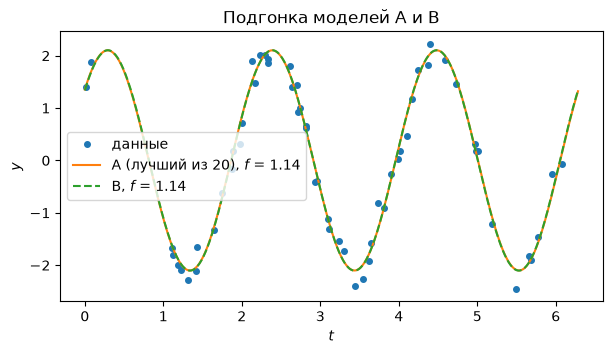

In [6]:
def f_A(x):
    r = x[0] * np.sin(x[1] * t + x[2]) - y
    return 0.5 * r @ r

def f_B(x):
    r = x[0] * np.sin(omega * t) + x[1] * np.cos(omega * t) - y
    return 0.5 * r @ r

res_A = [minimize(f_A, s, method="BFGS") for s in starts]
res_B = [minimize(f_B, s[:2], method="BFGS") for s in starts]
f_fin_A = np.array([r.fun for r in res_A])
f_fin_B = np.array([r.fun for r in res_B])

print("A, итоговые f по стартам:", np.sort(f_fin_A).round(3))
print("B, итоговые f по стартам:", np.sort(f_fin_B).round(6))

tol = 1e-4
share_A = np.mean(f_fin_A <= f_fin_A.min() + tol * (1 + f_fin_A.min()))
share_B = np.mean(f_fin_B <= f_fin_B.min() + tol * (1 + f_fin_B.min()))
print(f"доля стартов, пришедших к наименьшему f: A = {share_A:.0%}, B = {share_B:.0%}")

x_best_A = res_A[int(np.argmin(f_fin_A))].x
x_best_B = res_B[int(np.argmin(f_fin_B))].x
print("лучший x модели A:", x_best_A.round(4), " f =", f_fin_A.min().round(4))
print("лучший x модели B:", x_best_B.round(4), " f =", f_fin_B.min().round(4))

R = np.hypot(x_best_B[0], x_best_B[1])
phi = np.arctan2(x_best_B[1], x_best_B[0])
print(f"из B: амплитуда R = {R:.4f}, фаза phi = {phi:.4f} (истинные 2 и 0.7)")

tt = np.linspace(0, 2 * np.pi, 500)
plt.figure(figsize=(7, 3.5))
plt.plot(t, y, "o", ms=4, label="данные")
plt.plot(tt, x_best_A[0] * np.sin(x_best_A[1] * tt + x_best_A[2]),
         label=f"A (лучший из 20), $f$ = {f_fin_A.min():.2f}")
plt.plot(tt, x_best_B[0] * np.sin(omega * tt) + x_best_B[1] * np.cos(omega * tt), "--",
         label=f"B, $f$ = {f_fin_B.min():.2f}")
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.legend(); plt.title("Подгонка моделей A и B")
plt.show()

**Объяснение (пункт 3)**

**Ответ:** Задача B выпукла, и по главной теореме лекции любой её локальный минимум глобален: BFGS из
всех 20 стартов приходит к одному и тому же значению $f$ (доля 100%) — старт влияет только на число
итераций, не на ответ. Задача A не выпукла: BFGS останавливается в ближайшей стационарной точке, поэтому
лишь часть стартов попадает в глобальную яму, остальные застревают в локальных минимумах с заметно
большим $f$.

**Из B в A.** $x_1 \sin\omega t + x_2 \cos\omega t = R \sin(\omega t + \varphi)$ с
$R = \sqrt{x_1^2 + x_2^2}$, $\varphi = \operatorname{atan2}(x_2, x_1)$: амплитуда $x_1^A = R \approx 2$,
частота $x_2^A = \omega = 3$, фаза $x_3^A = \varphi \approx 0.7$ — численно это и получилось.

**Почему $f_A^{\min}$ чуть меньше и почему это не делает A лучше.** В A свободна ещё и частота — лишняя
степень свободы позволяет чуть подстроиться под конкретную реализацию шума, поэтому минимум по более
широкому классу моделей не больше (B — это срез A при $x_2 = 3$). Выигрыш — подгонка шума, а не сигнала.
Платим же за него невыпуклостью: ответ A зависит от старта, без мультистарта легко получить плохой
локальный минимум, тогда как B решается надёжно из любого старта (и вообще явной формулой линейного МНК).

## Бонус (+1 балл). Проекция не растягивает

Пусть $\Omega$ — выпуклое замкнутое множество, $P(p)$ — проекция точки $p$ на $\Omega$ (решение задачи $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$). Докажите, что для любых $p, q$

$$\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert .$$

Подсказка: запишите условие оптимальности для $P(p)$ с пробной точкой $y = P(q)$ и для $P(q)$ с $y = P(p)$, сложите и примените неравенство Коши–Буняковского. Проверьте численно на шаре ($P(p) = p / \max(1, \Vert p\Vert)$) и на кубе $[-1, 1]^n$ (`np.clip`) для 1000 случайных пар точек.

**Ответ:** Обозначим $u = P(p)$, $v = P(q)$. Условие оптимальности задачи проекции (раздел 7, пример 2):
$(P(z) - z)^\top (y - P(z)) \ge 0$ для всех $y \in \Omega$.

Для $P(p)$ возьмём пробную точку $y = v \in \Omega$, для $P(q)$ — точку $y = u \in \Omega$:

$$(u - p)^\top (v - u) \ge 0, \qquad (v - q)^\top (u - v) \ge 0 .$$

Перепишем второе как $(q - v)^\top (v - u) \ge 0$ и сложим с первым:

$$(u - p + q - v)^\top (v - u) \ge 0
\quad\Longleftrightarrow\quad
(q - p)^\top (v - u) \ge (v - u)^\top (v - u) = \Vert v - u\Vert^2 .$$

По неравенству Коши–Буняковского $\Vert v - u\Vert^2 \le (q - p)^\top (v - u) \le \Vert q - p\Vert \cdot \Vert v - u\Vert$.
Если $\Vert v - u\Vert = 0$, неравенство тривиально; иначе делим на $\Vert v - u\Vert$:

$$\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert . \qquad \blacksquare$$

In [7]:
# ваш код

---

Перед сдачей: `Kernel → Restart Kernel and Run All Cells`, убедитесь, что ни одна ячейка не падает и все ответы заполнены. Файл — `submissions/hw02/<фамилия>.ipynb`, дальше по [инструкции](../CONTRIBUTING.md).